## Data preparation

Plate reader data is loaded using pr.load_platereader_data, which parses the raw instrument output and merges the platemap to annotate each well with its construct identity.

In [2]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [3]:
data, platemap = pr.load_platereader_data(
    data_file="20251031-141455-cytation5-pure-timecourse-Aptamers_TO3Biotin-deGFP--biotek-cdk.txt",
    platemap_file="20251031_TO3Biotin_deGFP_platemap.tsv",
    platereader="biotek-cdk",  
)

# Background subtraction — remove negative control signal from all wells at each timepoint
neg_mean = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].mean()
data["Data"] = data.apply(
    lambda row: row["Data"] - neg_mean.loc[(row["Time"], row["Read"])], axis=1
)
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

data.to_csv("20251031_TO3Biotin_deGFP-Background-sbtrkt.csv")
print(f"Saved background-subtracted data: {len(data)} rows")

Saved background-subtracted data: 2190 rows


## Timecourse analysis

### Full timecourse
The full timecourse plots show the raw fluorescence data for each construct across the entire 
experiment duration, excluding the negative control. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval. The aptamer reporter 
(transcription) and mScarlet (translation) are plotted separately.

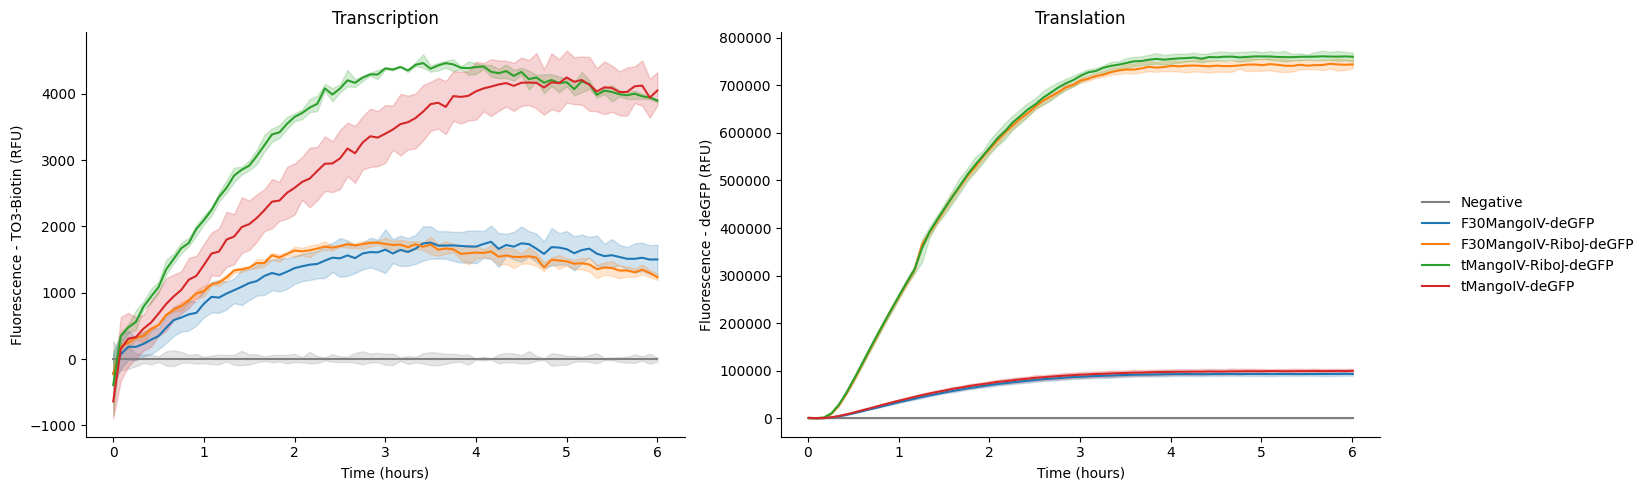

In [4]:
deGFP_colours = {
    "Negative": "grey",
    "F30MangoIV-deGFP": "tab:blue",
    "F30MangoIV-RiboJ-deGFP": "tab:orange",
    "tMangoIV-RiboJ-deGFP": "tab:green",
    "tMangoIV-deGFP": "tab:red"
}

data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, read, ylabel in [(axes[0], "TO3-Biotin", "Fluorescence - TO3-Biotin (RFU)"),
                          (axes[1], "GFP-Gext", "Fluorescence - deGFP (RFU)")]:
    subset = data[(data["Read"] == read)]
    sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name",
                 palette=deGFP_colours, ax=ax)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

axes[0].set_title("Transcription")
axes[1].set_title("Translation")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### First hour
The first-hour plots show the early period of the experiment, split by aptamer variant to allow 
direct comparison of RiboJ and non-RiboJ constructs. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval.

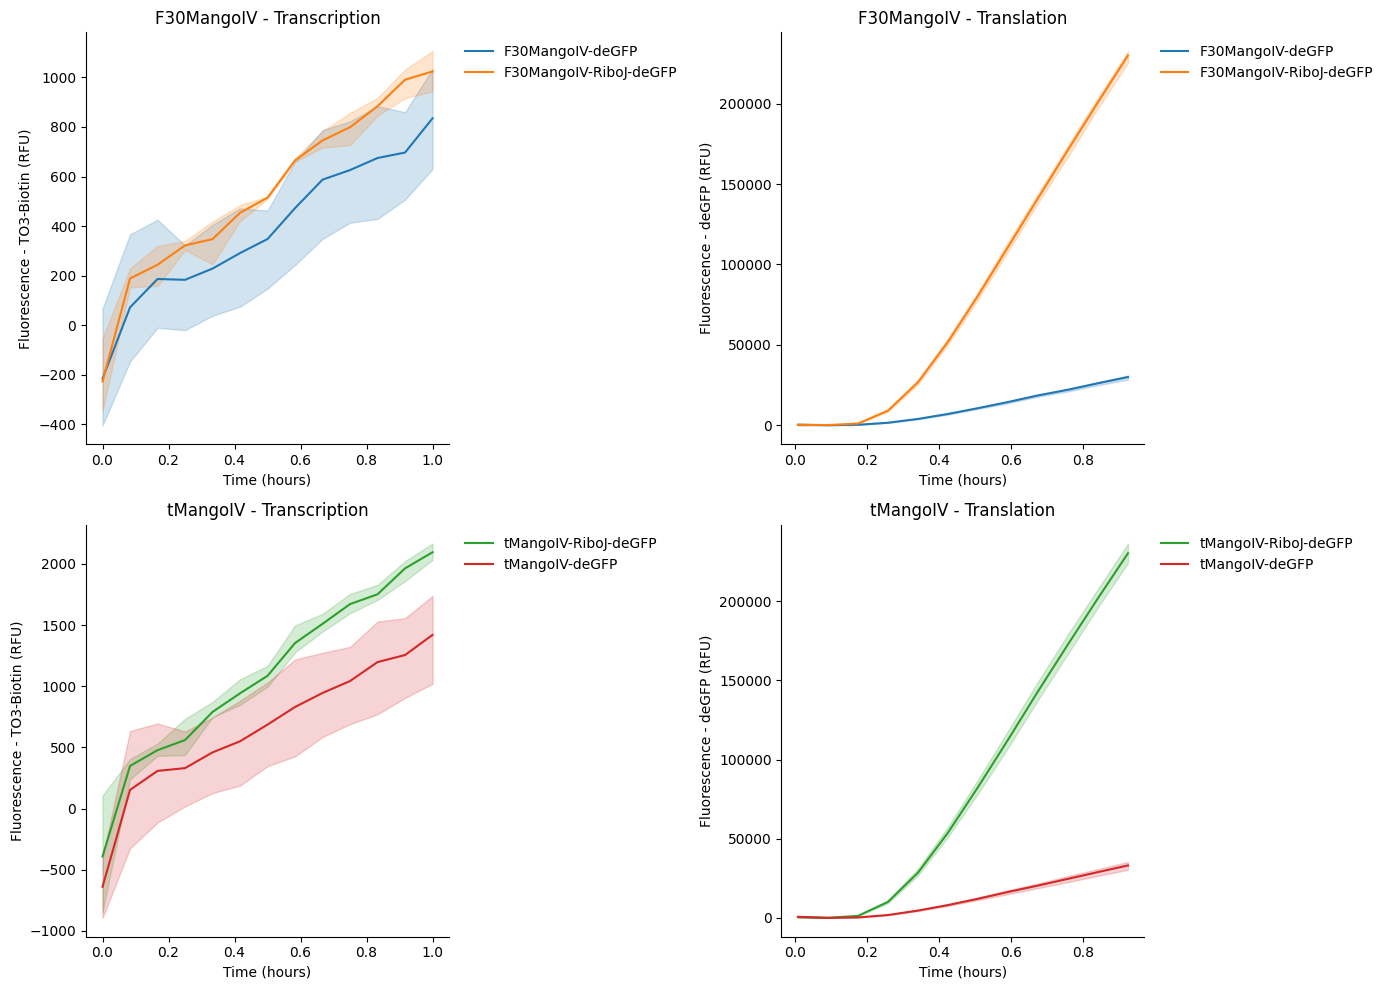

In [6]:
one_hour = pd.Timedelta("1 hour")
variants = {"F30MangoIV": 0, "tMangoIV": 1}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for variant, row in variants.items():
    names = data[(data["Name"].str.contains(variant)) & (data["Name"] != "Negative")]["Name"].unique()
    for col, read, ylabel in [(0, "TO3-Biotin", "Fluorescence - TO3-Biotin (RFU)"),
                               (1, "GFP-Gext", "Fluorescence - deGFP (RFU)")]:
        subset = data[
            (data["Read"] == read) &
            (data["Name"].isin(names)) &
            (data["Time"] <= one_hour)
        ]
        sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name",
                     palette={n: deGFP_colours[n] for n in names},
                     ax=axes[row, col])
        axes[row, col].set_xlabel("Time (hours)")
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].get_legend().remove()

    axes[row, 0].set_title(f"{variant} - Transcription")
    axes[row, 1].set_title(f"{variant} - Translation")

    for col in [0, 1]:
        handles, labels = axes[row, col].get_legend_handles_labels()
        axes[row, col].legend(handles, labels, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("./figures/20251031_TO3Biotin_deGFP-Background_sbtrkt", dpi=600, bbox_inches="tight")
plt.show()